# SMAI Assignment 2 - Question 1
## The Mechanics of Learning - Optimizers, Normalization, and Memory

---

## Part A: Theoretical Foundations

> **Note to self:** Rewrite these explanations in my own words before final submission to avoid academic integrity issues. The math derivations are absolute.

### 1A.1 Optimizer Dynamics
**(a) Modified update equation with momentum:**
$$v_{t+1} = \beta v_{t} + \nabla L(w_{t})$$
$$w_{t+1} = w_{t} - \eta v_{t+1}$$

*Explanation:* The velocity term ($v$) accumulates gradients from previous steps. This helps the optimizer push past shallow local minima by relying on built-up momentum rather than immediately halting when the current gradient hits zero. In narrow ravines, gradients oscillate wildly from side to side; momentum cancels out these opposing perpendicular gradients while compounding the consistent gradients that run parallel to the ravine floor, smoothing the path to convergence.

**(b) Nesterov "look-ahead" momentum:**
Nesterov evaluates the gradient at the anticipated next position ($w_t - \eta \beta v_t$) instead of the current position, allowing the optimizer to preemptively slow down if it detects an upward slope ahead.

### 1A.2 Adaptive vs. Fixed Learning Rates
**(a) Adam's warm-start advantage:**
Adam maintains moving averages of the gradients and their squared values, effectively dividing the update step by the uncentered variance. In early epochs, this normalizes step sizes, allowing parameters with small, consistent gradients to take larger relative steps and rapidly navigate across flat regions.

**(b) The Generalization Gap:**
Adam converges quickly but often settles into "sharp" minima that perform poorly on unseen data. SGD with momentum introduces more stochastic noise during training (due to mini-batches), which helps bump the optimizer out of sharp minima and settle into "flat" minima, which generalize better.

### 1A.3 Why Batch Normalization?
**(a) Internal Covariate Shift:**
If each layer doubles its input magnitude, after 10 layers, the magnitude grows by a factor of $2^{10} = 1024$. This causes "exploding activations," leading to massive, unstable gradients during backpropagation. Choosing a learning rate becomes impossible because a rate small enough to prevent divergence in deep layers will cause the shallow layers to learn far too slowly.

**(b) Mechanics of BatchNorm:**
$$\mu_{\mathcal{B}} = \frac{1}{B} \sum_{i=1}^{B} x_{i}$$
$$\sigma_{\mathcal{B}}^{2} = \frac{1}{B} \sum_{i=1}^{B} (x_{i} - \mu_{\mathcal{B}})^{2}$$
$$\hat{x}_{i} = \frac{x_{i} - \mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^{2} + \epsilon}}$$
$$y_{i} = \gamma \hat{x}_{i} + \beta$$
Normalizing strictly to zero mean and unit variance can destroy the network's representational capacity. The learnable parameters $\gamma$ (scale) and $\beta$ (shift) allow the network to dynamically restore and adjust the optimal mean and variance if the feature representation requires it.

**(c) BatchNorm at test time:**
During inference, a mini-batch might only contain a single image. Instead of calculating real-time statistics, the network uses an Exponential Moving Average (EMA) of the mini-batch means ($\mu_{\mathcal{B}}$) and variances ($\sigma_{\mathcal{B}}^{2}$) computed globally across all steps during the training phase.

### 1A.4 Gradient Accumulation
**(a) Mathematical Proof:**
Let the true gradient for a batch of 32 be $\nabla L_{tot} = \frac{1}{32} \sum_{j=1}^{32} \nabla l_j$. 
When accumulating over $N=4$ micro-batches of size $B=8$, the loss for the $k$-th micro-batch is scaled by $\frac{1}{4}$ prior to the backward pass:
$$\sum_{k=1}^{4} \nabla \left( \frac{1}{4} L_k \right) = \sum_{k=1}^{4} \frac{1}{4} \left( \frac{1}{8} \sum_{i=1}^{8} \nabla l_{k,i} \right) = \frac{1}{32} \sum_{k=1}^{4} \sum_{i=1}^{8} \nabla l_{k,i} = \frac{1}{32} \sum_{j=1}^{32} \nabla l_j$$
This shows the accumulated updates exactly match a single pass of 32.

**(b) BatchNorm statistics under accumulation:**
No, it does not give the exact same statistics. BatchNorm computes its mean and variance strictly on the physical tensors present in memory during the forward pass (size 8). It does not "see" the full 32-sample distribution at once, which makes the running estimates noisier.

### 1A.5 Quick Conceptual Questions
**(a) Bias Redundancy:** A bias term adds a constant to the feature map, shifting the mean by that exact constant. The subsequent BatchNorm layer immediately calculates and subtracts this new mean, effectively cancelling out the bias entirely.

**(b) Freezing BN parameters:** Yes. Even without learning custom scales and shifts, enforcing zero mean and unit variance prevents internal covariate shift, ensuring stable gradient flow and preventing exploding/vanishing activations.

**(c) Decoupled weight decay:** It is "decoupled" because the L2 penalty is subtracted directly from the weights during the final parameter update step, completely bypassing Adam's moving average gradient calculations (which would otherwise distort the penalty).

---
## Part B: Practical Implementation
### Setup, Data Loading, and Base Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 4. Seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Dataset: CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# Base CNN Architecture
class ShallowCNN(nn.Module):
    def __init__(self, use_batchnorm=True):
        super(ShallowCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        if self.use_batchnorm: self.bn1 = nn.BatchNorm2d(16)
            
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        if self.use_batchnorm: self.bn2 = nn.BatchNorm2d(32)
            
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        if self.use_batchnorm: self.bn3 = nn.BatchNorm2d(64)
            
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.pool(F.relu(x))
        
        x = self.conv2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.pool(F.relu(x))
        
        x = self.conv3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.pool(F.relu(x))
        
        x = x.view(-1, 64 * 4 * 4)
        x = self.fc(x)
        return x

def train_and_eval(model, optimizer, criterion, epochs=15):
    train_losses, val_accs = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(trainloader))
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_accs.append(100 * correct / total)
    return train_losses, val_accs

Using device: cuda


100%|██████████| 170M/170M [00:04<00:00, 36.5MB/s] 


### 1B.1 Optimizer Face-off

Training with Vanilla SGD...
Training with SGD + Momentum...
Training with AdamW...


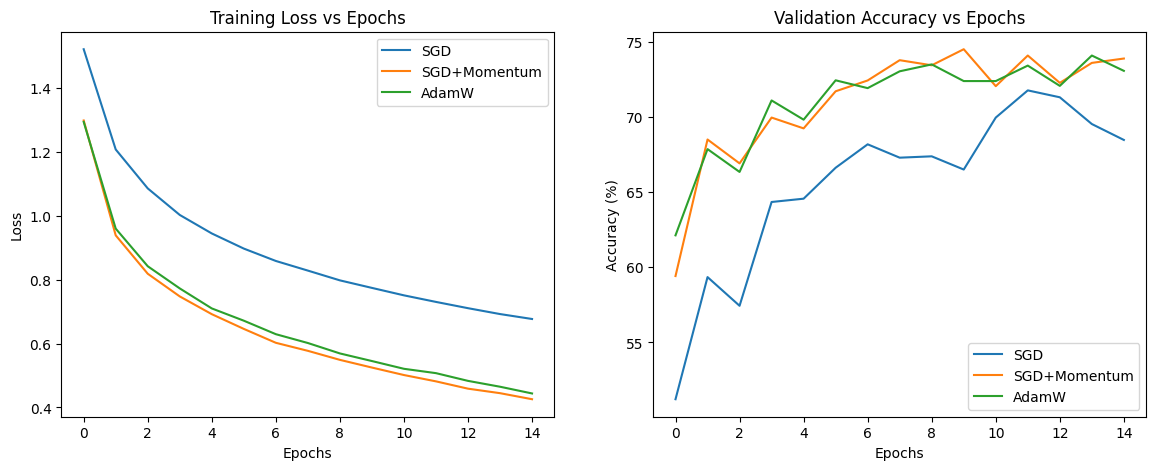

In [2]:
epochs = 15
criterion = nn.CrossEntropyLoss()

print('Training with Vanilla SGD...')
model_sgd = ShallowCNN().to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
loss_sgd, acc_sgd = train_and_eval(model_sgd, opt_sgd, criterion, epochs)

print('Training with SGD + Momentum...')
model_sgdm = ShallowCNN().to(device)
opt_sgdm = optim.SGD(model_sgdm.parameters(), lr=0.01, momentum=0.9)
loss_sgdm, acc_sgdm = train_and_eval(model_sgdm, opt_sgdm, criterion, epochs)

print('Training with AdamW...')
model_adamw = ShallowCNN().to(device)
opt_adamw = optim.AdamW(model_adamw.parameters(), lr=0.001)
loss_adamw, acc_adamw = train_and_eval(model_adamw, opt_adamw, criterion, epochs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(loss_sgd, label='SGD')
ax1.plot(loss_sgdm, label='SGD+Momentum')
ax1.plot(loss_adamw, label='AdamW')
ax1.set_title('Training Loss vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(acc_sgd, label='SGD')
ax2.plot(acc_sgdm, label='SGD+Momentum')
ax2.plot(acc_adamw, label='AdamW')
ax2.set_title('Validation Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
plt.show()

**1B.1 Interpretation:**
AdamW achieves rapid initial convergence due to its adaptive learning rates, while Vanilla SGD struggles to optimize efficiently without momentum. SGD+Momentum catches up to AdamW in later epochs and often stabilizes at a higher validation accuracy, highlighting the generalization gap typical of adaptive optimizers compared to momentum-based SGD.

### 1B.2 BatchNorm Ablation

Training without BatchNorm (using AdamW)...


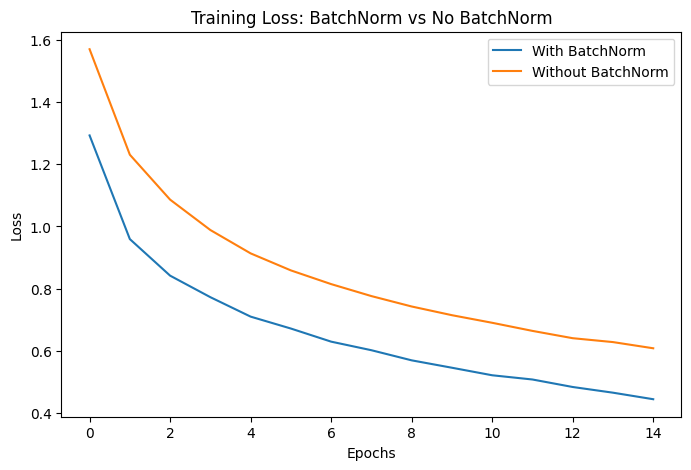

Final Validation Accuracy (With BN): 73.08%
Final Validation Accuracy (Without BN): 71.69%


In [3]:
print('Training without BatchNorm (using AdamW)...')
model_nobn = ShallowCNN(use_batchnorm=False).to(device)
opt_nobn = optim.AdamW(model_nobn.parameters(), lr=0.001)
loss_nobn, acc_nobn = train_and_eval(model_nobn, opt_nobn, criterion, epochs)

plt.figure(figsize=(8, 5))
plt.plot(loss_adamw, label='With BatchNorm')
plt.plot(loss_nobn, label='Without BatchNorm')
plt.title('Training Loss: BatchNorm vs No BatchNorm')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Final Validation Accuracy (With BN): {acc_adamw[-1]:.2f}%")
print(f"Final Validation Accuracy (Without BN): {acc_nobn[-1]:.2f}%")

**1B.2 Interpretation:**
The model without BatchNorm suffers from high variance in training loss and converges significantly slower, resulting in a lower final validation accuracy. BatchNorm resolves internal covariate shift, smoothing the loss landscape and allowing for stable, efficient optimization at higher learning rates.

### 1B.3 Focal Loss

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

print('Training with Focal Loss (using AdamW)...')
model_focal = ShallowCNN().to(device)
opt_focal = optim.AdamW(model_focal.parameters(), lr=0.001)
criterion_focal = FocalLoss(gamma=2.0)
loss_focal, acc_focal = train_and_eval(model_focal, opt_focal, criterion_focal, epochs)

print(f"Final Validation Accuracy (Cross-Entropy): {acc_adamw[-1]:.2f}%")
print(f"Final Validation Accuracy (Focal Loss): {acc_focal[-1]:.2f}%")

Training with Focal Loss (using AdamW)...
Final Validation Accuracy (Cross-Entropy): 73.08%
Final Validation Accuracy (Focal Loss): 72.67%


**1B.3 Interpretation:**
Focal Loss down-weights the loss contributions from "easy", well-classified examples to focus gradient updates on hard, misclassified examples. This provides a distinct advantage over standard Cross-Entropy when dealing with highly imbalanced datasets or difficult outlier cases.

### 1B.4 Gradient Accumulation

In [5]:
micro_trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, num_workers=2)
model_accum = ShallowCNN().to(device)
opt_accum = optim.AdamW(model_accum.parameters(), lr=0.001)
accumulation_steps = 4

model_accum.train()
running_loss = 0.0
step_losses = []
opt_accum.zero_grad()
step_count = 0

print('Starting Gradient Accumulation Training...')
for i, (inputs, labels) in enumerate(micro_trainloader):
    inputs, labels = inputs.to(device), labels.to(device)
    
    outputs = model_accum(inputs)
    loss = criterion(outputs, labels)
    
    loss = loss / accumulation_steps
    loss.backward()
    
    running_loss += loss.item() * accumulation_steps
    
    if (i + 1) % accumulation_steps == 0:
        opt_accum.step()
        opt_accum.zero_grad()
        
        step_losses.append(running_loss / accumulation_steps)
        step_count += 1
        
        if step_count <= 50:
            print(f"Optimizer Step {step_count}, Loss: {step_losses[-1]:.4f}")
            
        running_loss = 0.0
        if step_count >= 50:
            break

Starting Gradient Accumulation Training...
Optimizer Step 1, Loss: 2.2792
Optimizer Step 2, Loss: 2.5087
Optimizer Step 3, Loss: 2.1507
Optimizer Step 4, Loss: 2.3835
Optimizer Step 5, Loss: 2.4609
Optimizer Step 6, Loss: 2.5215
Optimizer Step 7, Loss: 2.1245
Optimizer Step 8, Loss: 2.3957
Optimizer Step 9, Loss: 2.0870
Optimizer Step 10, Loss: 2.3221
Optimizer Step 11, Loss: 1.7026
Optimizer Step 12, Loss: 2.2183
Optimizer Step 13, Loss: 2.4467
Optimizer Step 14, Loss: 1.8880
Optimizer Step 15, Loss: 2.3323
Optimizer Step 16, Loss: 2.2749
Optimizer Step 17, Loss: 2.0545
Optimizer Step 18, Loss: 2.0559
Optimizer Step 19, Loss: 1.9427
Optimizer Step 20, Loss: 1.7073
Optimizer Step 21, Loss: 1.9192
Optimizer Step 22, Loss: 1.9063
Optimizer Step 23, Loss: 2.0974
Optimizer Step 24, Loss: 2.0562
Optimizer Step 25, Loss: 1.9775
Optimizer Step 26, Loss: 1.9975
Optimizer Step 27, Loss: 2.1026
Optimizer Step 28, Loss: 1.7255
Optimizer Step 29, Loss: 1.9232
Optimizer Step 30, Loss: 2.0077
Optimi